In [50]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Task 3: Decision Tree Classification

## Objective
To build a *Decision Tree Classifier* that predicts whether a customer will purchase a bank product or service based on their demographic and behavioral data using the *Bank Marketing dataset* from the *UCI Machine Learning Repository*.

In [32]:
df=pd.read_csv("bank.csv",sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [33]:
df.shape

(4521, 17)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [35]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [36]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [37]:
categorical_features=df.select_dtypes(include="object")
categorical_features.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [38]:
le=LabelEncoder()
for column in categorical_features.columns:
    df[column]=le.fit_transform(df[column])

In [39]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


In [40]:
df["y"].value_counts()

y
0    4000
1     521
Name: count, dtype: int64

In [41]:
X=df.drop("y",axis=1)
y=df["y"]

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
smote = SMOTE(random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)

In [44]:
dt= DecisionTreeClassifier(max_depth=5)
dt.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred=dt.predict(X_test)

In [46]:
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.8198895027624309


<Axes: >

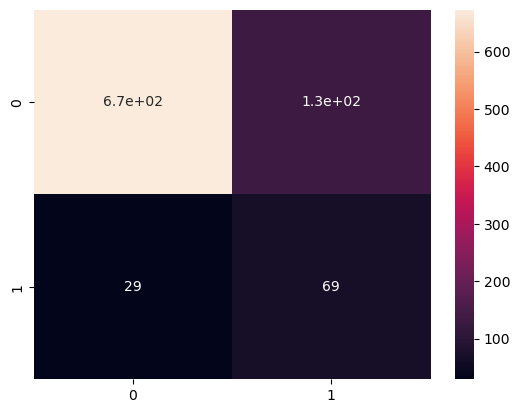

In [47]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

In [48]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89       807
           1       0.34      0.70      0.46        98

    accuracy                           0.82       905
   macro avg       0.65      0.77      0.68       905
weighted avg       0.89      0.82      0.85       905



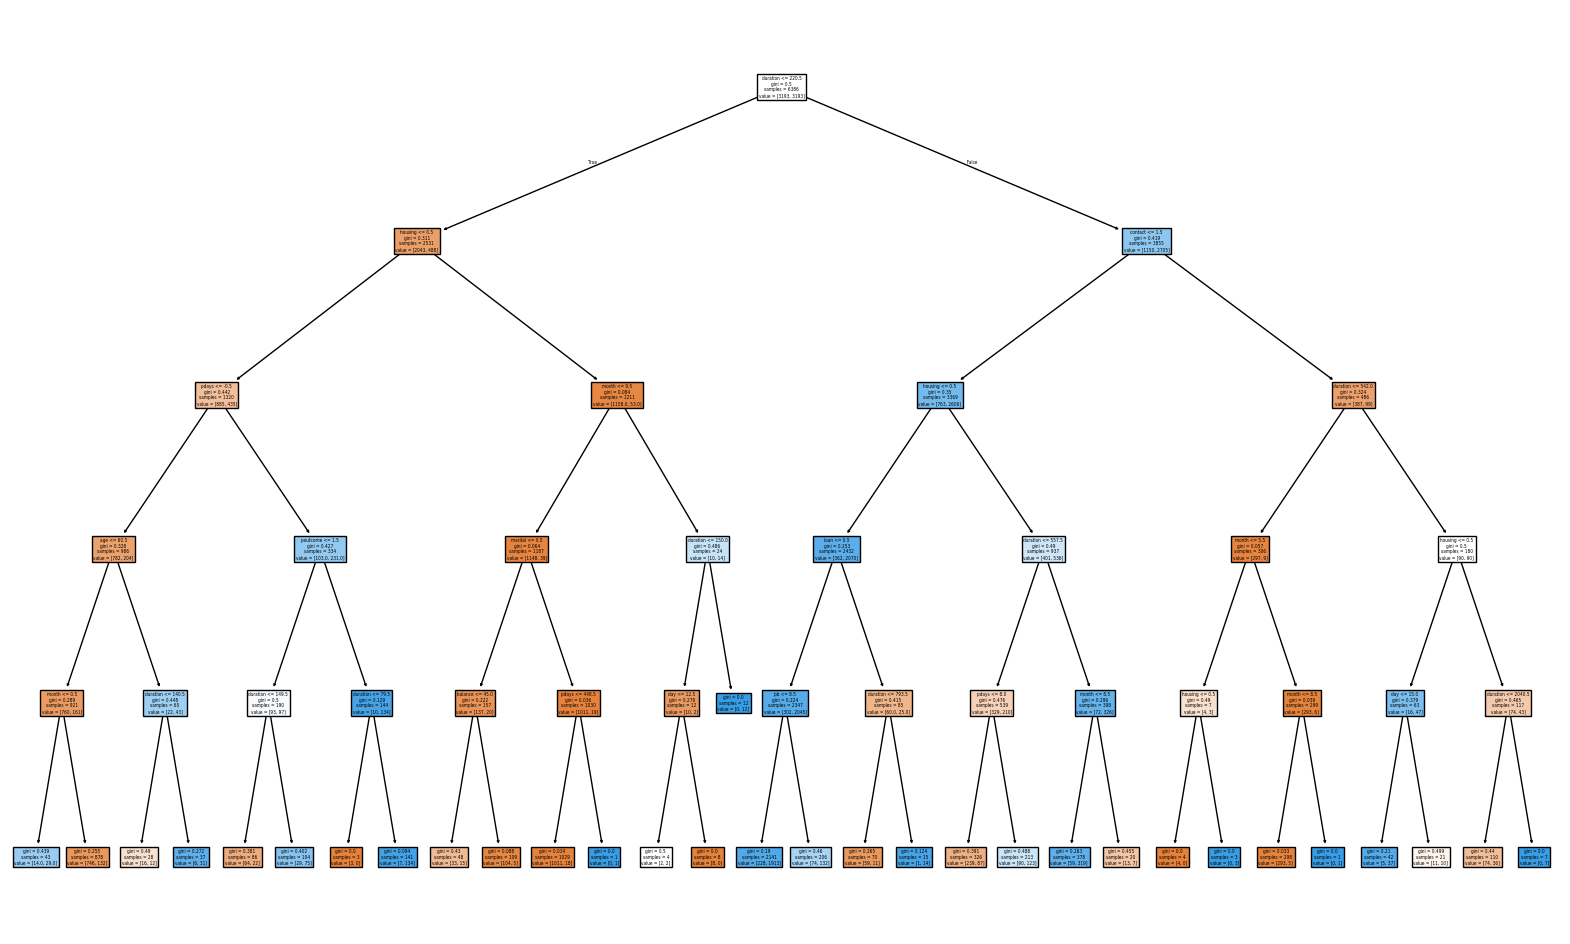

In [51]:
plt.figure(figsize=(20,12))
plot_tree(dt,filled=True,feature_names=X.columns)
plt.show()

# Insights

- The Decision Tree Classifier can effectively predict whether a customer will subscribe to a bank term deposit (yes or no).
- Features like age, job, marital status, balance, and previous campaign outcome play an important role in predicting customer decisions.
- Customers who had a successful outcome in previous campaigns are more likely to subscribe again.
- The duration of the last contact with the customer strongly influences the prediction.
- Most customers in the dataset did not subscribe, showing the dataset is slightly imbalanced.
- The decision tree model helps to visualize decision rules, making it easy to understand how predictions are made.
- Using a max depth limit prevents the model from overfitting and improves generalization.
- The model performance can be evaluated using accuracy, confusion matrix, and classification report.
- Decision trees are useful because they are simple, interpretable, and easy to visualize.